In [1]:
import torch

import torch.nn as nn #for building and traning neural network
import torch.optim as optim #optimizer
from torchvision import datasets, transforms  #loading eminist datasets
from torch.utils.data import DataLoader #for efficientlty batch and shuffle data
import matplotlib.pyplot as plt #for plotting and visiualization

import seaborn as sns 
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report #ealuating our model performance using tolols likr confusion metric ets  
from sklearn.metrics import accuracy_score



In [2]:
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


In [3]:
# #------Data transforms-------- 
# transform = transforms.Compose([
#     transforms.ToTensor(),  # this convert our image from PIL format to numpy array of pytorch tensor and also scales pixwlva;ue from 0 o 255 to 0 to 1
#     transforms.Normalize((0.1307,),(0.3081,))# mean and standard deviation  #Standard normalization for mnist  , this is system of operations applied to each image before it fed to model
    
# ])


#-----Load datasets-----
train_dataset = datasets.MNIST(root = './data',train = True,transform = train_transform,download = True)  # train = true loads 60000 images these images where model learn from
test_dataset = datasets.MNIST(root = './data',train = False,transform = test_transform , download = True) # train = false loads 10000 images these never seen by model and used to evaluate hoe modelperforms
# transform ka use isliye ki every image goes through pre processing steps  




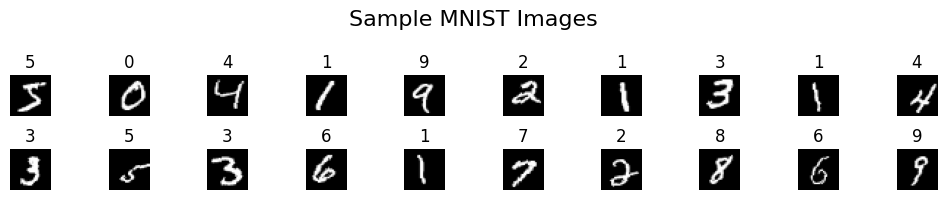

In [4]:
# traning of mnist dataset is done by using dataloader
train_loader = DataLoader(train_dataset,batch_size=64,shuffle = True)  # dataloader is powerful utility that helps in efficiently loading data in batches , softing data , handling parallism 
test_loader = DataLoader(test_dataset,batch_size=1000,shuffle = False)
# train ;oader is for training dataset 64 means model will process 64 images at once before updating weights
# shuffle btata hai ki model use diffrent data in each epoch
# test loader is used to test dataset

#-----------------EDA = show image samples-----
def show_samples(dataset, n=20):  # we define a small function that displays first 20 images from traning set along with their actual digit labels
    plt.figure(figsize=(10,2))
    for i in range(n):
        image , label  = dataset[i]
        plt.subplot(2,n//2,i+1)
        plt.imshow(image.squeeze(),cmap='gray')
        plt.title(label)
        plt.axis('off') 
    plt.suptitle("Sample MNIST Images",fontsize = 16)
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

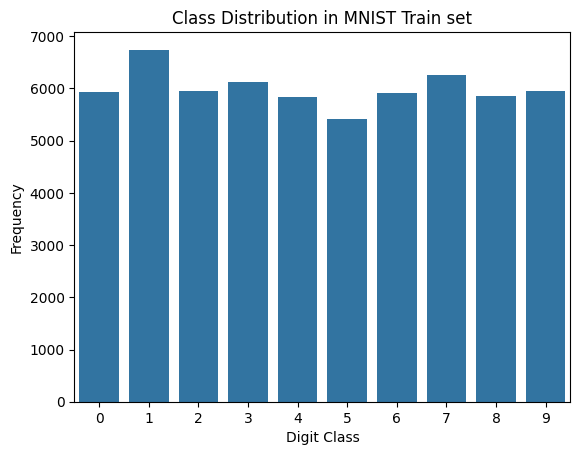

In [5]:
# -------EDA: Check class distribution----analyze how digits are distriuted in training set
labels = [label for _, label in train_dataset]
sns.countplot(x=labels) # we extract the data from traning dataset and use countplt to visualize how many samples for each digit class from 0 to 9
plt.title("Class Distribution in MNIST Train set")
plt.xlabel("Digit Class")
plt.ylabel("Frequency")
plt.show()

In [6]:
#---------CNN modek definetion-----
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1,32,3,padding = 0)
        self.bn1 = nn.BatchNorm2d(32)  # it is convolutional layer define as conv1 takes 1 input channel with 16 filters of dimension 3x3   we add padding to ensure output size remain same as input
        self.pool = nn.MaxPool2d(2,2)  # it reduces the size of feature map 2x2 pooling halfs the height and weight
        self.conv2 = nn.Conv2d(32,16,3,padding = 0)
        self.bn2 = nn.BatchNorm2d(16)  # second convolutuinal layer which takes 16 output channel from previous layer and apply 32 filters of 3x3 dimension
          # we flatten the feature map and its time it to pass them through a fully connected layer with 128 neurons  # finally we have our output layer a fully connected layer with neuromns one for each digits from 0 to 9
        self.dropout1 = nn.Dropout(0.10)
        self.fc1 = nn.Linear(16*5*5,12)
        

    def forward(self,x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.dropout1(x)
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 400)
        # x = torch.relu(self.fc1(x))
        return self.fc1(x)

model = CNNModel()
         
         
 
    

In [7]:
#-----------loss and optimizer------------
criterion = nn.CrossEntropyLoss()  # Losss function
optimizer = optim.Adam(model.parameters(),lr = 0.001)  # optimizers it adjust the learning rate for each parameter individually making it faster and more efficient during traning   this learning rate definrs how big step the optimizer takes while updating weights in each iteration


In [ ]:
#------------Traning loop---------
epochs = 15  # number of times the model will go throufh training

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()  # this ensures that certain layers like dropout and batch normalization if present behved appropriately during traning
    running_loss = 0.0
    correct = 0
    total = 0
    for images , labels in train_loader:
        optimizer.zero_grad()   # to reset the gradients from previous step
        outputs = model(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step() # that updates the model weight using those gradients
        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted ==labels).sum().item()

    avg_loss = 100 * (running_loss / len(train_loader))
    avg_acc = 100 * (correct / total)
    train_losses.append(avg_loss)
    train_accuracies.append(avg_acc)
    print(f"Epoch [{epoch + 1}/{epochs}] | Loss: {avg_loss:.4f} | Training Accuracy: {avg_acc:.2f}%")
        
    

Epoch [1/15] | Loss: 41.9595 | Training Accuracy: 87.52%
Epoch [2/15] | Loss: 17.9076 | Training Accuracy: 94.50%
Epoch [3/15] | Loss: 14.9476 | Training Accuracy: 95.47%
Epoch [4/15] | Loss: 12.8328 | Training Accuracy: 96.02%
Epoch [5/15] | Loss: 11.9555 | Training Accuracy: 96.33%
Epoch [6/15] | Loss: 10.8294 | Training Accuracy: 96.63%
Epoch [7/15] | Loss: 10.6571 | Training Accuracy: 96.79%
Epoch [8/15] | Loss: 9.6548 | Training Accuracy: 97.05%
Epoch [9/15] | Loss: 9.3738 | Training Accuracy: 97.07%
Epoch [10/15] | Loss: 9.2720 | Training Accuracy: 97.21%
Epoch [11/15] | Loss: 9.1050 | Training Accuracy: 97.13%
Epoch [12/15] | Loss: 8.6934 | Training Accuracy: 97.27%
Epoch [13/15] | Loss: 8.4061 | Training Accuracy: 97.44%


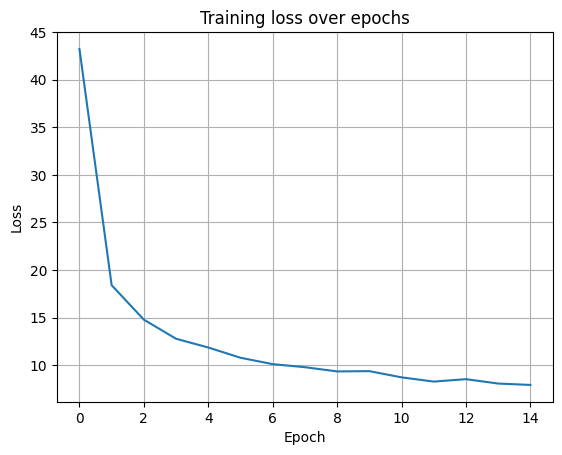

In [ ]:
# ----Plot traning loss---
plt.plot(train_losses)
plt.title("Training loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [ ]:
#---------Evaluation----------
model.eval()  # turns off dropout,batch norm training behaviour
#required during testing

# Create empty list to store results
all_preds = [] #predicted classes
all_labels = []  #true labels
with torch.no_grad():   #disable gradient calculation  saves memory and speeds up testing  no backpropogation during evaluation 
    for images , labels in test_loader:   #loads batches from test dataset
        outputs = model(images)    #forward pass   produces class scores
        _, predicted = torch.max(outputs,1)   #get predicted class, takes the class with highest score,returns predicted digits 0-9
        all_preds.extend(predicted.numpy())  # stores prediction and labels
        all_labels.extend(labels.numpy())


#acccuracy and classification report

print("\nClassification Report:")   # main kaam iska hi hai  , this is from sklearn.metrices and give detailed performance metrices
print(classification_report(all_labels, all_preds))




'''CLASSIFICATION REPORT JO NEECHE HAI USKA IDEA

JO NUMBER DIYE HAI 0-9 = WO PERFORMANCE FOR EACH DIGIT LASS BTATE HAI

PRECISION = OUT OF ALL PREDICTED AS HIS CLASS HOW MANY WERE CORRECT 
CLASS 0= PRECISION = 0.99  MEANS 99% OF PREDICTED 0 WERE ACTUALLY 0


RECALL = OUT OF ALL ACTUAL SAMPLES OF THIS CLAS HOW MANY WERE FOUND
RECALL = 0.99  MEANS MODEL FOUND 99% OF REAL ZEROES

F1-SCORE = HARMONIC MEAN OF PRECISION AND RECALL BALANCES BOTH METRICES

SUPPORT = NUMBWER OF TRUE SAMPLES IN TEST SET FOR THAT CLASS 
CLASS 0 = SUPPORT = 980     THERE WERE 980 IMAGES OF 0'''


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



'CLASSIFICATION REPORT JO NEECHE HAI USKA IDEA\n\nJO NUMBER DIYE HAI 0-9 = WO PERFORMANCE FOR EACH DIGIT LASS BTATE HAI\n\nPRECISION = OUT OF ALL PREDICTED AS HIS CLASS HOW MANY WERE CORRECT \nCLASS 0= PRECISION = 0.99  MEANS 99% OF PREDICTED 0 WERE ACTUALLY 0\n\n\nRECALL = OUT OF ALL ACTUAL SAMPLES OF THIS CLAS HOW MANY WERE FOUND\nRECALL = 0.99  MEANS MODEL FOUND 99% OF REAL ZEROES\n\nF1-SCORE = HARMONIC MEAN OF PRECISION AND RECALL BALANCES BOTH METRICES\n\nSUPPORT = NUMBWER OF TRUE SAMPLES IN TEST SET FOR THAT CLASS \nCLASS 0 = SUPPORT = 980     THERE WERE 980 IMAGES OF 0'

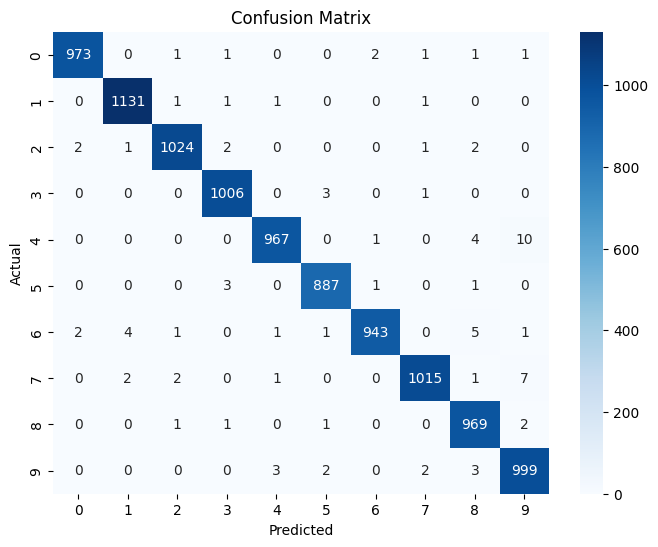

In [ ]:
# Confusion matrix   gives us a detailed breakdownof models predictioncompared to actual labels

conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize = (8,6))
sns.heatmap(conf_matrix, annot=True, fmt = 'd' , cmap = "Blues", xticklabels = range(10), yticklabels = range(10))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


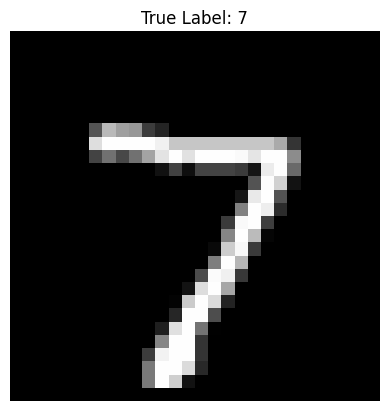

Predicted Class: 7


In [ ]:
#------------Interferwnce on one image------   now we test our model on single image
sample_img, sample_label = test_dataset[0]
plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title(f"True Label: {sample_label}")
plt.axis('off')
plt.show()

sample_tensor = sample_img.unsqueeze(0)   #  the title of image is true level that so that we can later compare it to models prediction
# since our model expects a batch of images we need to add a extra dimension to convert single image into batc of size one using squeeze command
with torch.no_grad():
    output = model(sample_tensor)
    predicted_class = torch.argmax(output).item()
    print(f"Predicted Class: {predicted_class}")

In [ ]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print("Trainable:", trainable_params)
print("Non-trainable:", non_trainable)

Trainable: 9852
Non-trainable: 0


In [ ]:
acc = accuracy_score(all_labels,all_preds)
print("Accuracy:",acc*100,"%")

Accuracy: 99.14 %
